# 18.4 Neural Network Policies

##### Environment

In [1]:
import gymnasium as gym

env = gym.make("CartPole-v1")

##### Agent

In [2]:
print("Observation space: ", env.observation_space)
print("Action space:", env.action_space)

Observation space:  Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)
Action space: Discrete(2)


In [3]:
n_inputs = env.observation_space.shape[0]
n_outputs = env.action_space.n

print("n_inputs:", n_inputs)
print("n_outputs:", n_outputs)


n_inputs: 4
n_outputs: 2


In [4]:
import tensorflow as tf

agent = tf.keras.models.Sequential([
    tf.keras.layers.Dense(5, activation="selu", kernel_initializer="lecun_normal", input_shape=(n_inputs,)),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

2023-08-22 05:57:16.172233: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-08-22 05:57:18.485459: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-08-22 05:57:18.592275: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-08-22 05:57:18.592818: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so retur

##### Training

In [5]:
# Help functions
from typing import Any, Callable, Dict, List, Sequence, SupportsFloat, Tuple

import numpy as np


def play_one_step(
    env: gym.Env,
    obs: Tuple[float, float, float, float],
    agent: tf.keras.models.Model,
    loss_fn: Callable[[tf.Tensor, tf.Tensor], tf.Tensor],
) -> Tuple[tf.Tensor, Tuple[float, float, float, float], SupportsFloat, bool, bool, Dict[str, Any]]:
    with tf.GradientTape() as tape:
        left_proba = agent(obs[np.newaxis])
        action = tf.random.uniform((1, 1)) > left_proba
        y_target = tf.constant([[1.]]) - tf.cast(action, dtype=tf.float32)
        loss = tf.reduce_mean(loss_fn(y_target, left_proba))
    grads = tape.gradient(loss, agent.trainable_weights)
    obs, reward, terminated, truncated, info = env.step(int(action[0, 0].numpy()))
    return grads, obs, reward, terminated, truncated, info


def play_multiple_episodes(
    env: gym.Env,
    agent: tf.keras.models.Model,
    loss_fn: Callable[[tf.Tensor, tf.Tensor], tf.Tensor],
    n_episodes: int,
    max_steps: int,
) -> Tuple[List[List[tf.Tensor]], List[List[SupportsFloat]]]:
    grads_episodes = []
    rewards_episodes = []
    for i_episode in range(n_episodes):
        obs, info = env.reset()
        grads_episode = []
        rewards_episode = []
        for step in range(max_steps):
            grads, obs, reward, terminated, truncated, info = play_one_step(
                env=env,
                obs=obs,
                agent=agent,
                loss_fn=loss_fn,
            )
            grads_episode.append(grads)
            rewards_episode.append(reward)
            if terminated:
                break
        grads_episodes.append(grads_episode)
        rewards_episodes.append(rewards_episode)
    return grads_episodes, rewards_episodes


def discount_rewards(rewards_episode: List[SupportsFloat], discount_factor: float) -> np.ndarray:
    discounted_rewards: List[float] = np.asarray(rewards_episode)
    for step in range(len(rewards_episode) - 2, -1, -1):
        discounted_rewards[step] += discount_factor * discounted_rewards[step + 1]
    return discounted_rewards

def discount_and_normalize_rewards(rewards_episodes: Sequence[Sequence[SupportsFloat]], discount_factor: float) -> List[np.ndarray]:
    rewards_discounted = [discount_rewards(rewards_episode=rewards_episode, discount_factor=discount_factor) for rewards_episode in rewards_episodes]
    rewards_flat = np.concatenate(rewards_discounted)
    mean = rewards_flat.mean()
    std = rewards_flat.std()
    return [(rewards_episode - mean) / std for rewards_episode in rewards_discounted]
    
print(discount_rewards([10, 0, -50], 0.8))
print(discount_and_normalize_rewards([[10, 0, -50], [10, 20]], 0.8))

[-22 -40 -50]
[array([-0.28435071, -0.86597718, -1.18910299]), array([1.26665318, 1.0727777 ])]


In [6]:
# Hyperparameters
n_epochs = 150
n_episodes_per_epoch = 10
max_steps = 200
discount_factor = 0.95

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
loss_fn = tf.keras.losses.binary_crossentropy

In [7]:
# Train
for i_epoch in range(n_epochs):
    grads_episodes, rewards_episodes = play_multiple_episodes(
        env=env,
        agent=agent,
        loss_fn=loss_fn,
        n_episodes=n_episodes_per_epoch,
        max_steps=max_steps,
    )
    rewards_norm = discount_and_normalize_rewards(rewards_episodes=rewards_episodes, discount_factor=discount_factor)
    
    grads_mean = []
    for i_var in range(len(agent.trainable_variables)):
        grads_mean.append(
            tf.reduce_mean(
                [
                    grads[i_var] * reward 
                    for grads_steps, rewards_steps in zip(grads_episodes, rewards_episodes)
                    for grads, reward in zip(grads_steps, rewards_steps)
                ],
                axis=0,
            )
        )
    optimizer.apply_gradients(zip(grads_mean, agent.trainable_variables))
    

##### Application

In [8]:
env = gym.make("CartPole-v1", render_mode="human")

rewards_episode = []
for i_episode in range(500):
    reward_episode = 0
    observation, info = env.reset()
    for i_step in range(200):
        action = int(np.random.uniform() > agent.predict(observation[np.newaxis])[0, 0] )
        observation, reward, terminated, truncated, info = env.step(action)
        reward_episode += reward
        if terminated:
            break
    rewards_episode.append(reward_episode)
env.close()

1/1 [==============================] - 0s 40ms/step


In [9]:
import pandas as pd

s_rewards = pd.Series(rewards_episode)
s_rewards.describe()

count    500.000000
mean      16.204000
std        6.215436
min        8.000000
25%       12.000000
50%       15.000000
75%       18.000000
max       50.000000
dtype: float64

<Axes: >

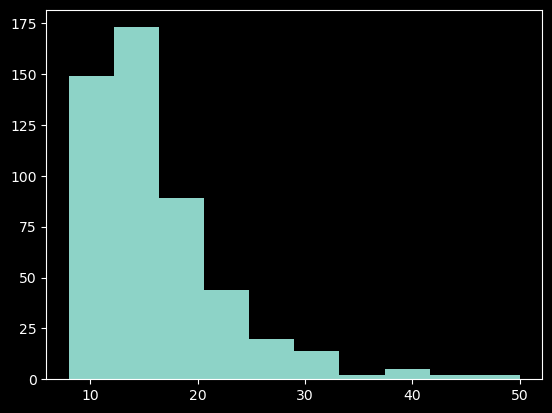

In [10]:
s_rewards.hist(grid=False)